# Dataset Overview: Chat Distribution Analysis

Analyze the distributions of:
1. **Sessions per project**
2. **Messages per session**
3. **Characters per message**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/classifications/classifications_for_analysis.csv")
# Keep one row per message (label_rank == 1)
df = df[df["label_rank"] == 1].copy()
print(f"Total messages: {len(df):,}")
print(f"Total sessions (sha): {df['sha'].nunique():,}")
print(f"Total projects: {df['repository_full_name'].nunique():,}")

Total messages: 74,998
Total sessions (sha): 11,579
Total projects: 1,300


In [2]:
# Compute the three distributions
sessions_per_project = df.groupby("repository_full_name")["sha"].nunique()
messages_per_session = df.groupby("sha")["index_in_chat"].nunique()
chars_per_message = df["content"].fillna("").str.len()

In [3]:
def compute_stats(series):
    return {
        "count": len(series),
        "mean": series.mean(),
        "std": series.std(),
        "min": series.min(),
        "median": series.median(),
        "p75": series.quantile(0.75),
        "p90": series.quantile(0.90),
        "p95": series.quantile(0.95),
        "max": series.max(),
    }


def make_buckets(series, edges, labels):
    """Bucket a series and return percentage distribution."""
    buckets = pd.cut(series, bins=edges, labels=labels, right=True)
    return buckets.value_counts(normalize=True).mul(100)


def plot_distribution(
    lengths,
    stats,
    bucket_percentages,
    bucket_order,
    xlabel,
    hist_title,
    cdf_title,
    bucket_title,
    xlim_upper,
    bin_step=1,
):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        hist_title.split("Distribution")[0].strip() + " — Overview",
        fontsize=14,
        fontweight="bold",
        y=1.01,
    )

    # ── Plot 1: Histogram ──
    ax1 = axes[0, 0]
    lengths_plot = lengths[lengths <= xlim_upper]
    bins = np.arange(1, xlim_upper + 2, bin_step) - 0.5
    ax1.hist(lengths_plot, bins=bins, color="#4C72B0", alpha=0.8, edgecolor="white")
    ax1.axvline(
        stats["median"],
        color="#DD8452",
        linestyle="--",
        linewidth=2,
        label=f"Median: {stats['median']:.2f}",
    )
    ax1.axvline(
        stats["mean"],
        color="#55A868",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {stats['mean']:.2f}",
    )
    ax1.set_xlim(0, xlim_upper)
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel("Count")
    ax1.set_title(hist_title)
    ax1.legend()

    # ── Plot 2: CDF ──
    ax2 = axes[0, 1]
    sorted_lengths = np.sort(lengths.values)
    cdf = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
    mask = sorted_lengths <= xlim_upper
    ax2.plot(sorted_lengths[mask], cdf[mask], color="#4C72B0", linewidth=2)
    ax2.set_xlim(0, xlim_upper)
    ax2.set_ylim(0, 1.01)
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel("Cumulative probability")
    ax2.set_title(cdf_title)

    percentile_values = {
        "50th": stats["median"],
        "75th": stats["p75"],
        "90th": stats["p90"],
    }
    for pct_label, xval in percentile_values.items():
        if xval > xlim_upper:
            continue
        ax2.axvline(xval, color="#C44E52", linestyle=":", linewidth=1.8)
        x_text = min(xval + 1.0, xlim_upper * 0.95)
        y_val = np.searchsorted(sorted_lengths, xval, side="right") / len(
            sorted_lengths
        )
        ax2.annotate(
            f"{pct_label}: {xval:.1f}",
            xy=(xval, y_val),
            xytext=(x_text, min(y_val + 0.06, 0.98)),
            fontsize=9,
            color="#C44E52",
            arrowprops={"arrowstyle": "-", "color": "#C44E52", "lw": 0.8},
        )

    # ── Plot 3: Bucket bar chart ──
    ax3 = axes[1, 0]
    bucket_values = bucket_percentages.reindex(bucket_order)
    bars = ax3.bar(bucket_order, bucket_values.values, color="#8172B3", alpha=0.85)
    ax3.set_xlabel(xlabel + " (buckets)")
    ax3.set_ylabel("Percentage")
    ax3.set_title(bucket_title)
    ax3.set_ylim(0, max(bucket_values.max() * 1.2, 5))
    for bar, val in zip(bars, bucket_values.values):
        ax3.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    # ── Plot 4: Summary stats table ──
    ax4 = axes[1, 1]
    ax4.axis("off")
    table_data = [
        [k, f"{v:,.2f}" if isinstance(v, float) else f"{v:,}"] for k, v in stats.items()
    ]
    table = ax4.table(
        cellText=table_data,
        colLabels=["Statistic", "Value"],
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.5)
    ax4.set_title("Summary Statistics")

    fig.tight_layout()
    plt.show()

## 1. Sessions per Project

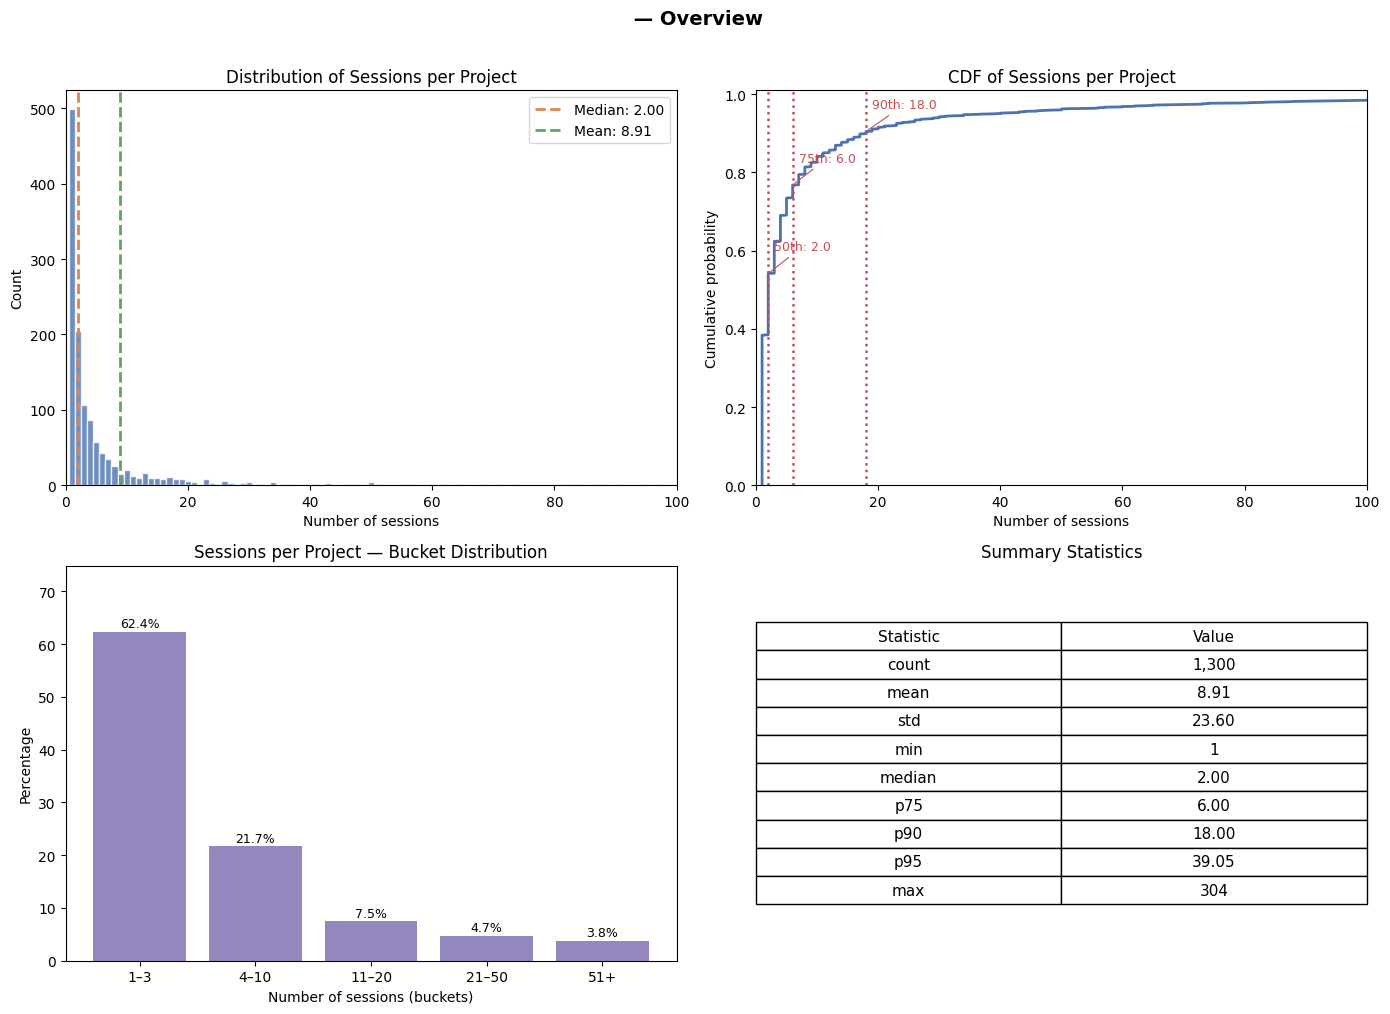

In [4]:
stats_spp = compute_stats(sessions_per_project)
bucket_edges_spp = [0, 3, 10, 20, 50, np.inf]
bucket_labels_spp = ["1\u20133", "4\u201310", "11\u201320", "21\u201350", "51+"]
bucket_pct_spp = make_buckets(sessions_per_project, bucket_edges_spp, bucket_labels_spp)

plot_distribution(
    lengths=sessions_per_project,
    stats=stats_spp,
    bucket_percentages=bucket_pct_spp,
    bucket_order=bucket_labels_spp,
    xlabel="Number of sessions",
    hist_title="Distribution of Sessions per Project",
    cdf_title="CDF of Sessions per Project",
    bucket_title="Sessions per Project — Bucket Distribution",
    xlim_upper=100,
)

## 2. Messages per Session

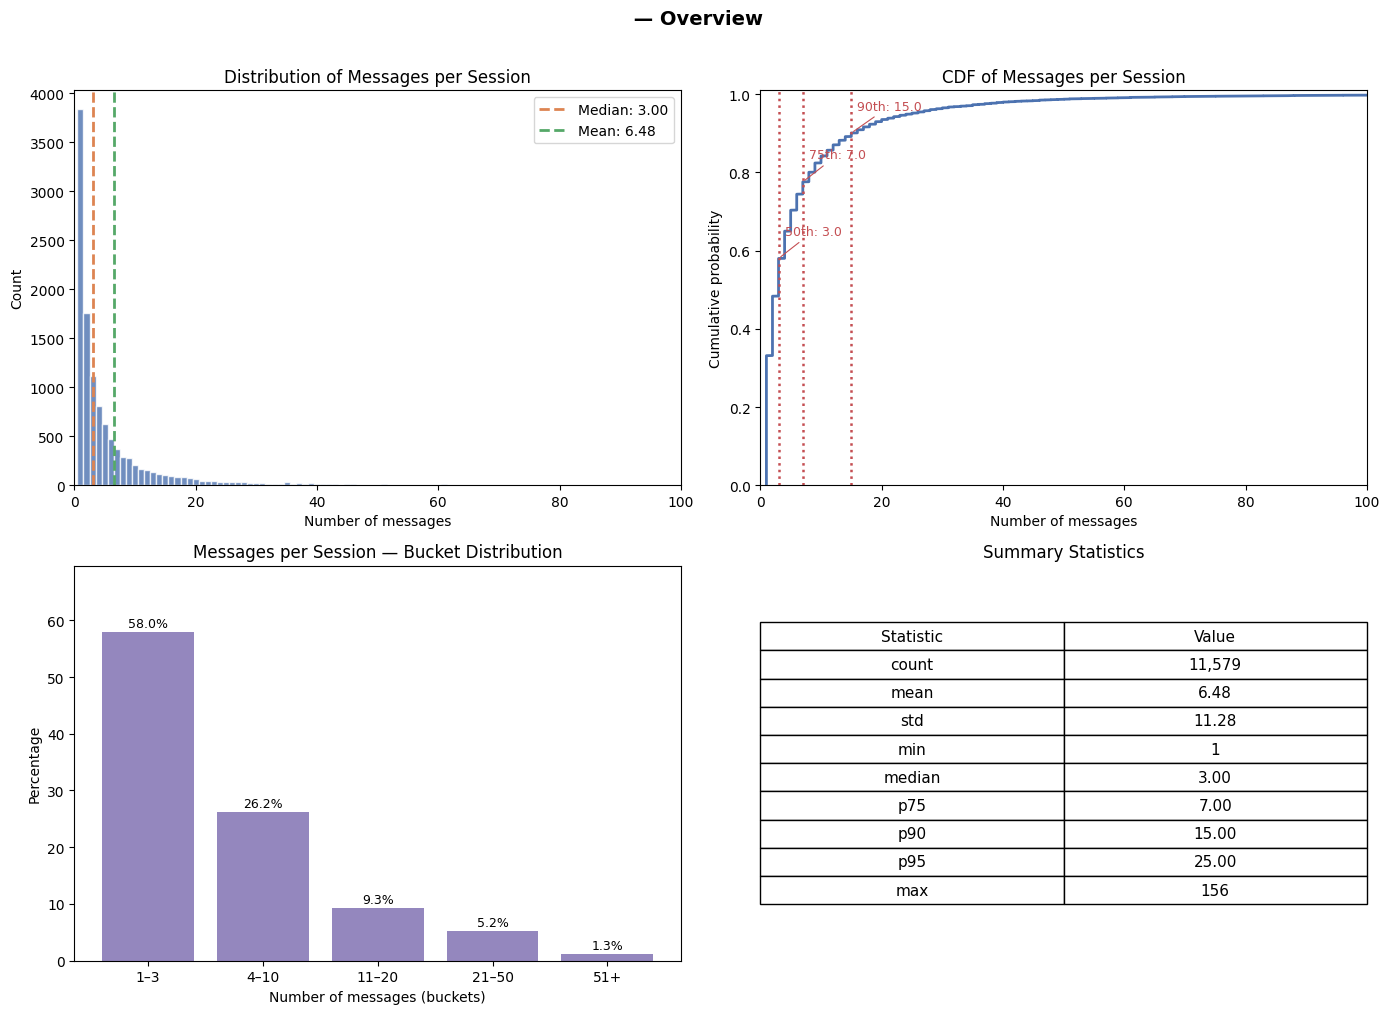

In [5]:
stats_mps = compute_stats(messages_per_session)
bucket_edges_mps = [0, 3, 10, 20, 50, np.inf]
bucket_labels_mps = ["1\u20133", "4\u201310", "11\u201320", "21\u201350", "51+"]
bucket_pct_mps = make_buckets(messages_per_session, bucket_edges_mps, bucket_labels_mps)

plot_distribution(
    lengths=messages_per_session,
    stats=stats_mps,
    bucket_percentages=bucket_pct_mps,
    bucket_order=bucket_labels_mps,
    xlabel="Number of messages",
    hist_title="Distribution of Messages per Session",
    cdf_title="CDF of Messages per Session",
    bucket_title="Messages per Session — Bucket Distribution",
    xlim_upper=100,
)

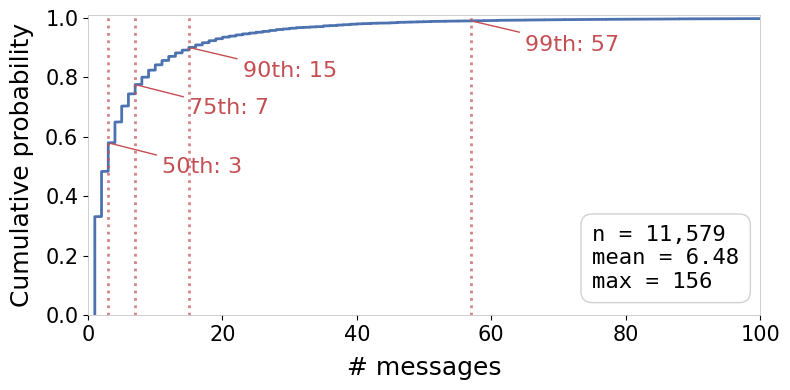

In [6]:
import numpy as np
import matplotlib.pyplot as plt

sorted_vals = np.sort(messages_per_session.values)
cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
xlim_upper = 100

fig, ax = plt.subplots(figsize=(8, 4))

# CDF curve
mask = sorted_vals <= xlim_upper
ax.plot(sorted_vals[mask], cdf[mask], color="#4C72B0", linewidth=2)

# Percentile annotations
percentiles = {
    "50th": messages_per_session.quantile(0.50),
    "75th": messages_per_session.quantile(0.75),
    "90th": messages_per_session.quantile(0.90),
    "99th": messages_per_session.quantile(0.99),
}

offsets = {
    "50th": (8, -0.1),
    "75th": (8, -0.1),
    "90th": (8, -0.1),
    "99th": (8, -0.1),
}

for label, xval in percentiles.items():
    if xval > xlim_upper:
        continue
    y_val = np.searchsorted(sorted_vals, xval, side="right") / len(sorted_vals)
    ax.axvline(xval, color="#C44E52", linestyle=":", linewidth=2, alpha=0.7)
    dx, dy = offsets[label]
    ax.annotate(
        f"{label}: {xval:.0f}",
        xy=(xval, y_val),
        xytext=(xval + dx, y_val + dy),
        fontsize=16,
        color="#C44E52",
        fontweight="medium",
        arrowprops={"arrowstyle": "-", "color": "#C44E52"},
    )

# Stats box
n = len(messages_per_session)
med = messages_per_session.median()
mean = messages_per_session.mean()
mx = messages_per_session.max()
stats_text = f"n = {n:,}\n" f"mean = {mean:.2f}\n" f"max = {mx:.0f}"
ax.text(
    0.75,
    0.3,
    stats_text,
    transform=ax.transAxes,
    fontsize=16,
    verticalalignment="top",
    horizontalalignment="left",
    bbox=dict(
        boxstyle="round,pad=0.5", facecolor="white", edgecolor="#cccccc", alpha=0.9
    ),
    family="monospace",
)

# Axis formatting
ax.set_xlim(0, xlim_upper)
ax.set_ylim(0, 1.01)
ax.set_xlabel("# messages", fontsize=18, labelpad=8)
ax.set_ylabel("Cumulative probability", fontsize=18, labelpad=8)
ax.tick_params(axis="both", labelsize=15)

for spine in ax.spines.values():
    spine.set_color("#bbbbbb")
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.savefig("results/session_length_cdf.pdf", bbox_inches="tight")
plt.show()

## 3. Characters per Message

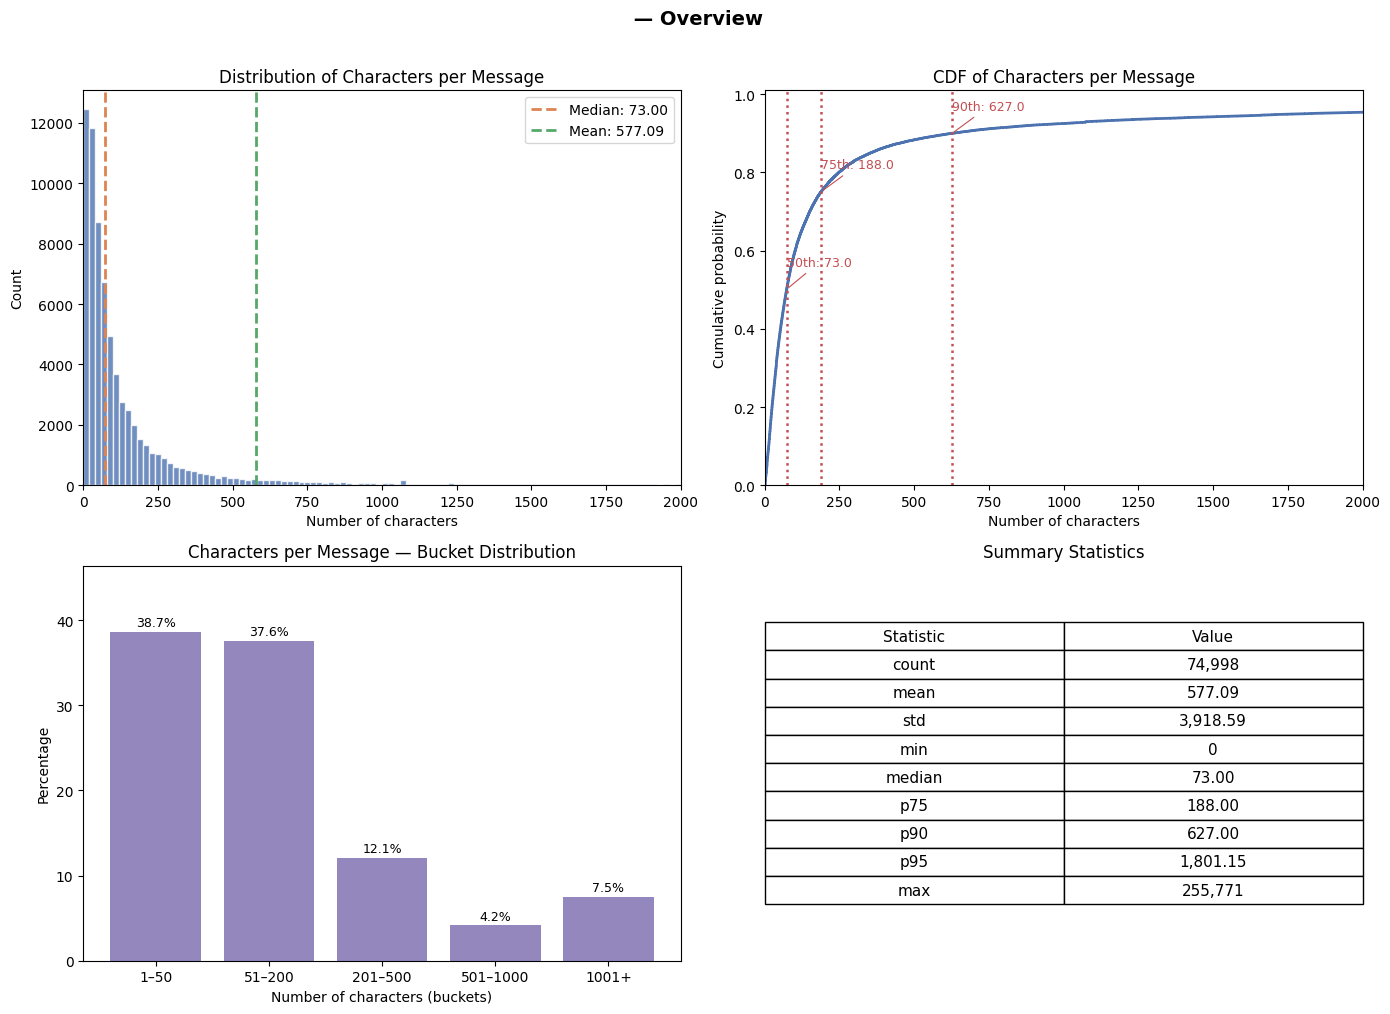

In [7]:
stats_cpm = compute_stats(chars_per_message)
bucket_edges_cpm = [0, 50, 200, 500, 1000, np.inf]
bucket_labels_cpm = [
    "1\u201350",
    "51\u2013200",
    "201\u2013500",
    "501\u20131000",
    "1001+",
]
bucket_pct_cpm = make_buckets(chars_per_message, bucket_edges_cpm, bucket_labels_cpm)

plot_distribution(
    lengths=chars_per_message,
    stats=stats_cpm,
    bucket_percentages=bucket_pct_cpm,
    bucket_order=bucket_labels_cpm,
    xlabel="Number of characters",
    hist_title="Distribution of Characters per Message",
    cdf_title="CDF of Characters per Message",
    bucket_title="Characters per Message — Bucket Distribution",
    xlim_upper=2000,
    bin_step=20,
)